In [1]:
# Setup
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = duckdb.sql(
    "SELECT * FROM read_parquet('../data/silver/nyc/listings.parquet')"
).df()
priced = df[df["price"].notna()].copy()

# Stay type (the 1 priced listing without a quote gets "unknown")
priced["stay_type"] = np.select(
    [priced["quote_nights"].isna(), priced["quote_nights"] < 28],
    ["unknown", "short stay"],
    default="monthly stay",
)

# License status
license_text = priced["license"].fillna("").str.lower()
priced["license_status"] = np.select(
    [license_text == "", license_text.str.contains("exempt")],
    ["no license", "exempt"],
    default="registration number",
)

priced["log10_price"] = np.log10(priced["price"])
print(priced["stay_type"].value_counts())

stay_type
monthly stay    16522
short stay       4993
Name: count, dtype: int64


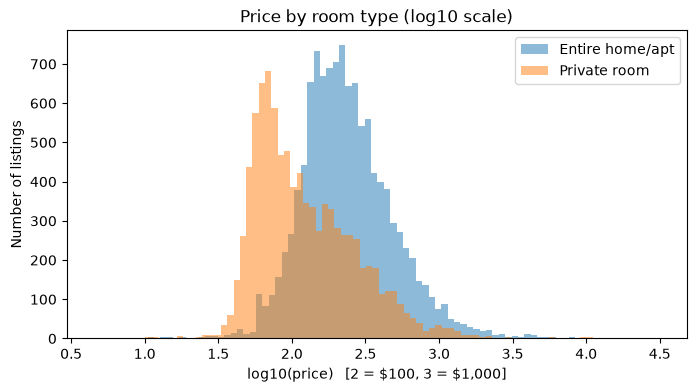

In [2]:
# Do room types explain the two humps?
fig, ax = plt.subplots(figsize=(8, 4))

for room in ["Entire home/apt", "Private room"]:
    values = priced.loc[priced["room_type"] == room, "log10_price"]
    ax.hist(values, bins=80, alpha=0.5, label=room)   # alpha = transparency

ax.set_title("Price by room type (log10 scale)")
ax.set_xlabel(r"log10(price)   [2 = \$100, 3 = \$1,000]")
ax.set_ylabel("Number of listings")
ax.legend()
plt.show()

In [3]:
# What kind of listings are registered short stays?
short = priced[priced["stay_type"] == "short stay"]

# margins=True adds row and column totals
print(pd.crosstab(short["room_type"], short["license_status"], margins=True))

license_status   exempt  no license  registration number   All
room_type                                                     
Entire home/apt    1081           7                  501  1589
Hotel room          459           0                    0   459
Private room        979         286                 1640  2905
Shared room           1           0                   39    40
All                2520         293                 2180  4993


In [4]:
# How does size change price?
homes = priced[priced["room_type"] == "Entire home/apt"].copy()

# Put bedroom counts into groups: (-1, 0] = 0, (0, 1] = 1, and so on
homes["bedroom_group"] = pd.cut(
    homes["bedrooms"],
    bins=[-1, 0, 1, 2, 3, 100],
    labels=["studio (0)", "1", "2", "3", "4+"],
)

table = (
    homes.groupby(["bedroom_group", "stay_type"], observed=True)["price"]
    .agg(["count", "median"])
    .round(0)
    .unstack("stay_type")   # turn stay types into columns
)
print(table)
print()
print("Entire homes with missing bedrooms:", homes["bedrooms"].isna().sum())

                     count                  median           
stay_type     monthly stay short stay monthly stay short stay
bedroom_group                                                
1                     4724        540        186.0      348.0
2                     2545        386        223.0      504.0
3                      952        217        282.0      590.0
4+                     335         95        454.0      968.0

Entire homes with missing bedrooms: 1743


In [5]:
# How does location change price?
main_rooms = priced[priced["room_type"].isin(["Entire home/apt", "Private room"])]

table = (
    main_rooms.groupby(["borough", "room_type", "stay_type"])["price"]
    .agg(["count", "median"])
    .round(0)
)
print(table)

                                            count  median
borough       room_type       stay_type                  
Bronx         Entire home/apt monthly stay    286   131.0
                              short stay       36   256.0
              Private room    monthly stay    400    68.0
                              short stay      102   152.0
Brooklyn      Entire home/apt monthly stay   3080   181.0
                              short stay      502   371.0
              Private room    monthly stay   2594    74.0
                              short stay      926   226.0
Manhattan     Entire home/apt monthly stay   5246   238.0
                              short stay      892   473.0
              Private room    monthly stay   1742    90.0
                              short stay     1262   343.0
Queens        Entire home/apt monthly stay   1207   148.0
                              short stay      154   312.0
              Private room    monthly stay   1552    69.0
              

In [6]:
# Are there enough similar listings to compare against?
priced["bedrooms_key"] = priced["bedrooms"].fillna(-1)   # -1 = unknown

levels = {
    "borough + room + stay":
        ["borough", "room_type", "stay_type"],
    "neighbourhood + room + stay":
        ["neighbourhood", "room_type", "stay_type"],
    "neighbourhood + room + stay + bedrooms":
        ["neighbourhood", "room_type", "stay_type", "bedrooms_key"],
}

for name, cols in levels.items():
    # transform("count") gives each listing the size of its own group
    group_size = priced.groupby(cols)["listing_id"].transform("count")
    print(name)
    for minimum in [5, 10, 20]:
        share = (group_size >= minimum).mean() * 100
        print(f"   groups with {minimum:>2}+ listings cover {share:5.1f}% of listings")

borough + room + stay
   groups with  5+ listings cover 100.0% of listings
   groups with 10+ listings cover  99.9% of listings
   groups with 20+ listings cover  99.9% of listings
neighbourhood + room + stay
   groups with  5+ listings cover  96.9% of listings
   groups with 10+ listings cover  92.8% of listings
   groups with 20+ listings cover  85.3% of listings
neighbourhood + room + stay + bedrooms
   groups with  5+ listings cover  88.7% of listings
   groups with 10+ listings cover  78.2% of listings
   groups with 20+ listings cover  65.0% of listings


In [7]:
# Cheapest and most expensive neighbourhoods
monthly_homes = priced[
    (priced["room_type"] == "Entire home/apt")
    & (priced["stay_type"] == "monthly stay")
]

nb = (
    monthly_homes.groupby(["borough", "neighbourhood"])["price"]
    .agg(listings="count", median_price="median")
)
nb = nb[nb["listings"] >= 30].sort_values("median_price")

print("Cheapest 5:\n", nb.head(5).round(0))
print("\nMost expensive 5:\n", nb.tail(5).round(0))
print("\nNeighbourhoods with 30+ listings:", len(nb))

Cheapest 5:
                          listings  median_price
borough  neighbourhood                         
Queens   Ozone Park            30         120.0
Brooklyn Brownsville           31         122.0
Queens   St. Albans            40         125.0
         Rosedale              42         128.0
Brooklyn Sheepshead Bay        31         130.0

Most expensive 5:
                              listings  median_price
borough   neighbourhood                            
Manhattan Midtown                 569         360.0
          Theater District         87         439.0
          SoHo                     85         442.0
          Greenwich Village        82         445.0
          Tribeca                  47         562.0

Neighbourhoods with 30+ listings: 60
